In [1]:
library('SelectSim')
library('ggpubr')
library('tidyverse')
library('tictoc')

Loading required package: ggplot2

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: AlmaLinux 9.3 (Shamrock Pampas Cat)

Matrix products: default
BLAS/LAPACK: /mnt/ndata/arvind/envs/selectsim_R/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Zurich
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] tictoc_1.2.1      lubridate_1.9.4   forcats_1.0.0     stringr_1.5.1    
 [5] dplyr_1.1.4       purrr_1.0.4       readr_2.1.5       tidyr_1.3.1      
 [9] tibble_3.2.1      tidyverse_2.0.0   ggpubr_0.6.0      ggpl

In [5]:
random_genes<- readRDS(file='/mnt/ndata/arvind/co_mutation_project_revision/oncogenic_syn_analysis/results/frequency_matched_miss_random_oncokb_multiple_gene_172_lists.rds')

In [6]:
length(random_genes)

[1] 10

In [7]:
radom_list<-random_genes[[1]]

In [8]:
# Filter the pan_can_run data object to required needs.
filter_run_data <- function(run_data,gene_order){
    final_run_data<-list()
    final_run_data$M$M$missense<-run_data$M$M$missense[gene_order,]
    #final_run_data$M$M$truncating<-run_data$M$M$truncating[gene_order,sample_order]
    final_run_data$alteration.class<- run_data$alteration.class[gene_order]
    final_run_data$sample.class<-run_data$sample.class
    final_run_data$M$tmb$missense<-run_data$M$tmb$missense
    #final_run_data$M$tmb$truncating<-run_data$M$tmb$truncating[sample_order,]
    return(final_run_data)
}

In [9]:
random_run<-readRDS('/mnt/ndata/arvind/co_mutation_project_revision/oncogenic_syn_analysis/data/pan_can_tcga_other_genes_run_data.rds')
oncokb_run_data<-readRDS('/mnt/ndata/arvind/co_mutation_project/data/processed/gams/pan_can_tcga_run_data.rds')

In [10]:
oncokb_genes <- names(unlist(radom_list))
random_genes <- unique(unlist(radom_list))

In [11]:
length(oncokb_genes)

[1] 172

In [12]:
random_run_missense<-filter_run_data(random_run,random_genes)
oncokb_run_data_missense<-filter_run_data(oncokb_run_data,oncokb_genes)

In [13]:
str(random_run_missense)
str(oncokb_run_data_missense)

List of 3
 $ M               :List of 2
  ..$ M  :List of 1
  .. ..$ missense: num [1:172, 1:9082] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:172] "AFF3" "PATL2" "CCL25" "ARHGEF39" ...
  .. .. .. ..$ : chr [1:9082] "TCGA-AB-2803-03" "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" ...
  ..$ tmb:List of 1
  .. ..$ missense:'data.frame':	9082 obs. of  2 variables:
  .. .. ..$ sample  : chr [1:9082] "TCGA-AB-2803-03" "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" ...
  .. .. ..$ mutation: num [1:9082] 13 56 47 40 422 214 588 14 8 7 ...
 $ alteration.class: Named chr [1:172] "MUT" "MUT" "MUT" "MUT" ...
  ..- attr(*, "names")= chr [1:172] "AFF3" "PATL2" "CCL25" "ARHGEF39" ...
 $ sample.class    : Named chr [1:9082] "LAML" "GBM" "GBM" "LAML" ...
  ..- attr(*, "names")= chr [1:9082] "TCGA-AB-2803-03" "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" ...
List of 3
 $ M               :List of 2
  ..$ M  :List of 1
  .. ..$ missense:

In [261]:
obj_oncokb <- selectX( M = oncokb_run_data_missense$M,
                sample.class = oncokb_run_data_missense$sample.class,
                alteration.class = oncokb_run_data_missense$alteration.class,
                n.cores = 30,
                min.freq = (0.001*9082),
                n.permut = 1000,
                lambda = 0.3,
                tao = 1,
                save.object = FALSE,
                verbose = FALSE,
                estimate_pairwise = FALSE,
                maxFDR = 0.25)

Total Time: 44.098 sec elapsed


In [262]:
obj_random <- selectX( M = random_run_missense$M,
                sample.class = random_run_missense$sample.class,
                alteration.class = random_run_missense$alteration.class,
                n.cores = 30,
                min.freq = (0.001*9082),
                n.permut = 1000,
                lambda = 0.3,
                tao = 1,
                save.object = FALSE,
                verbose = FALSE,
                estimate_pairwise = FALSE,
                maxFDR = 0.25)

Total Time: 45.059 sec elapsed


In [270]:
pan_can_result_df <- obj_oncokb$result
pan_can_random_result_df <- obj_random$result

In [271]:
pan_can_result_df$log_overlap <- log10(pan_can_result_df$w_overlap + 1)
pan_can_result_df$log_r_overlap <- log10(pan_can_result_df$w_r_overlap + 1)
pan_can_result_df <- pan_can_result_df %>% mutate(cat = case_when((FDR == TRUE & type=='ME') ~ 'Mutually Exclusive' ,
                                                                    (FDR == TRUE & type=='CO') ~ 'Co-occurent ', 
                                                                    FDR == FALSE ~ "Not Significant"))



In [272]:
pan_can_result_df %>% filter(FDR) %>% dim()
pan_can_result_df %>% filter(FDR) %>% count(type)

[1] 72 25

type,n
<chr>,<int>
CO,12
ME,60


In [273]:
log_breaks <- log10(c(1, 2, 5, 10, 20, 50, 100, 200, 600))
actual_labels <- c("1", "2", "5", "10", "20", "50", "100", "200", "600")

In [274]:
plot_actual <- ggscatter(pan_can_result_df,
                  x = "log_r_overlap",
                  y = "log_overlap", 
                  color = "cat",
                  palette = c("forestgreen", "purple", "grey93"), 
                  repel = TRUE,
                  alpha = 0.8) + 
        annotate("text",
               x = 2,
               y = 0,
               label = "Pairs:72",
               size = 6, 
               hjust = 0) +
        xlab("Expected weighted overlap (log10)") + 
        ylab("Observed weighted overlap (log10)") + geom_abline(slope = 1, intercept = 0,linetype=2)+
        ggtitle('TCGA Pan-Cancer\n 172 Genes \n Oncogenic mutations') + theme_pubr() +
        theme(legend.position = "top", 
             legend.title = element_blank(),
             plot.title = element_text(hjust = 0.5), 
             text = element_text(size = 14))+ 
        #scale_x_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        #scale_y_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))
        scale_x_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(600))
        ) +
        scale_y_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(600))
        )

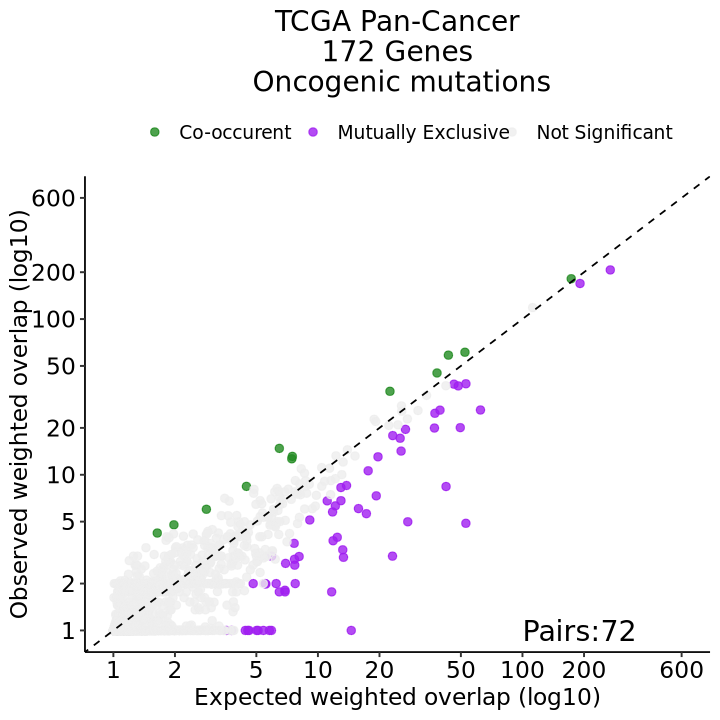

In [275]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot_actual

In [276]:
pan_can_random_result_df$log_overlap <- log10(pan_can_random_result_df$w_overlap + 1)
pan_can_random_result_df$log_r_overlap <- log10(pan_can_random_result_df$w_r_overlap + 1)
pan_can_random_result_df <- pan_can_random_result_df %>% mutate(cat = case_when((FDR == TRUE & type=='ME') ~ 'Mutually Exclusive' ,
                                                                    (FDR == TRUE & type=='CO') ~ 'Co-occurent ', 
                                                                    FDR == FALSE ~ "Not Significant"))


In [277]:
pan_can_random_result_df %>% filter(FDR) %>% dim()

[1]  7 25

In [278]:
plot_random <- ggscatter(pan_can_random_result_df,
                  x = "log_r_overlap",
                  y = "log_overlap", 
                  color = "cat",
                  palette = c("forestgreen","grey93"), 
                  repel = TRUE,
                  alpha = 0.8) + 
        annotate("text",
               x = 2,
               y = 0,
               label = "Pairs:8",
               size = 6, 
               hjust = 0)+
        xlab("Expected weighted overlap (log10)") + 
        ylab("Observed weighted overlap (log10)") + geom_abline(slope = 1, intercept = 0,linetype=2)+
        ggtitle('TCGA Pan-Cancer\n 172 Random Frequency Matched Genes \n hotspot mutations') + theme_pubr() +
        theme(legend.position = "top", 
             legend.title = element_blank(),
             plot.title = element_text(hjust = 0.5), 
             text = element_text(size = 14))+ 
        #scale_x_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        #scale_y_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        scale_x_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(800))
        ) +
        scale_y_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(800))
        )

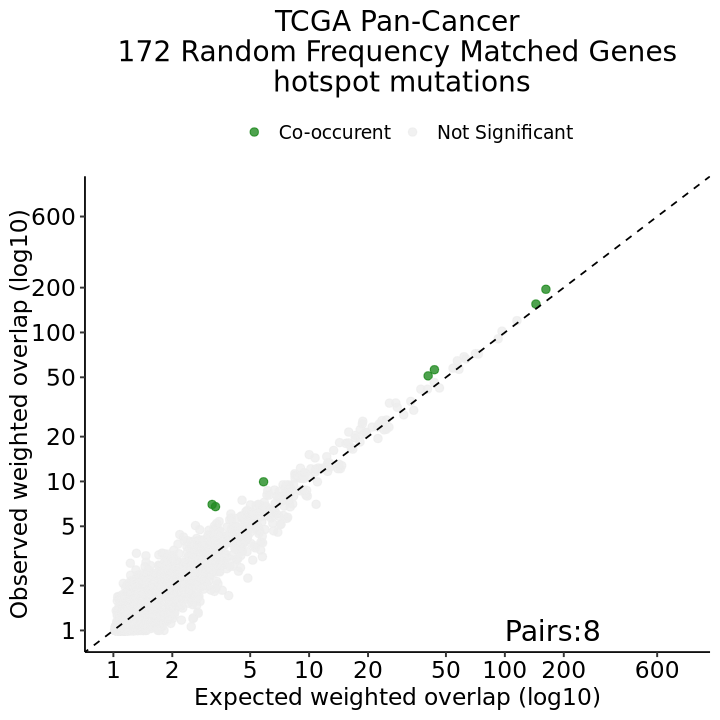

In [279]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot_random

In [280]:
p_all <- ggarrange(plot_actual,plot_random,nrow=1,ncol=2)

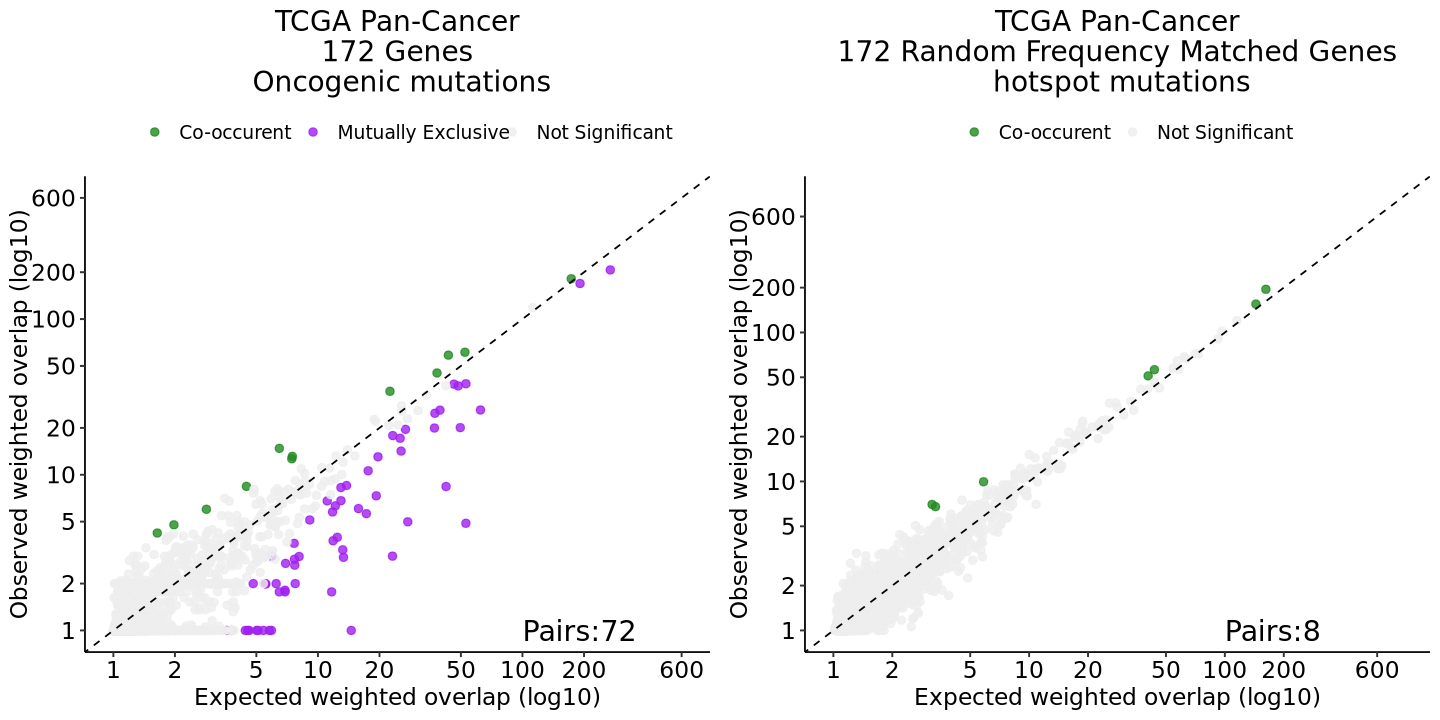

In [281]:
options(repr.plot.width=12, repr.plot.height=6)
p_all

# Multiple Random Runs

In [14]:
create_multiple_list<-readRDS(file='/mnt/ndata/arvind/co_mutation_project_revision/oncogenic_syn_analysis/results/frequency_matched_miss_random_oncokb_multiple_gene_172_lists.rds')

In [15]:
str(create_multiple_list,max.level = 1)

List of 10
 $ :List of 172
 $ :List of 172
 $ :List of 172
 $ :List of 172
 $ :List of 172
 $ :List of 172
 $ :List of 172
 $ :List of 172
 $ :List of 172
 $ :List of 172


In [16]:
random_run_missense_run_data<-list()
i=1
for(random_genes in create_multiple_list){
    random_run_missense_run_data[[i]]<-filter_run_data(random_run,unique(unlist(random_genes)))    
    i=i+1
}

In [17]:
length(random_run_missense_run_data)

[1] 10

In [288]:
random_run_missense_results <- list()
i=1
for(random_run_missense in random_run_missense_run_data){
    obj_random <- selectX( M = random_run_missense$M,
                sample.class = random_run_missense$sample.class,
                alteration.class = random_run_missense$alteration.class,
                n.cores = 40,
                min.freq = (0.001*9082),
                n.permut = 1000,
                lambda = 0.3,
                tao = 1,
                save.object = FALSE,
                verbose = FALSE,
                estimate_pairwise = FALSE,
                maxFDR = 0.25)
    random_run_missense_results[[i]]<-obj_random$result
    rm(obj_random)
    i=i+1
} 



Total Time: 45.502 sec elapsed
Total Time: 46.619 sec elapsed
Total Time: 44.868 sec elapsed
Total Time: 44.14 sec elapsed
Total Time: 46.557 sec elapsed
Total Time: 45.865 sec elapsed
Total Time: 45.236 sec elapsed
Total Time: 44.686 sec elapsed
Total Time: 48.955 sec elapsed
Total Time: 46.8 sec elapsed


In [289]:
significant_hit_counts<-c()
for(pan_can_random_result_df in random_run_missense_results){
    print(pan_can_random_result_df %>% filter(FDR) %>% nrow())    
    significant_hit_counts<-c(significant_hit_counts,pan_can_random_result_df %>% filter(FDR) %>% nrow())
}

[1] 7
[1] 5
[1] 4
[1] 4
[1] 4
[1] 2
[1] 2
[1] 4
[1] 2
[1] 2


In [293]:
saveRDS(random_run_missense_results,file='../results/pan_can_tcga_frequnecy_matched_miss_random_172_10_results.rds')

In [294]:
saveRDS(random_run_missense_run_data,file='../results/pan_can_tcga_frequnecy_matched_miss_random_172_10_run_data_list.rds')

In [297]:
pan_can_random_result_df<-random_run_missense_results[[6]]

In [298]:
pan_can_random_result_df$log_overlap <- log10(pan_can_random_result_df$w_overlap + 1)
pan_can_random_result_df$log_r_overlap <- log10(pan_can_random_result_df$w_r_overlap + 1)
pan_can_random_result_df <- pan_can_random_result_df %>% mutate(cat = case_when((FDR == TRUE & type=='ME') ~ 'Mutually Exclusive' ,
                                                                    (FDR == TRUE & type=='CO') ~ 'Co-occurent ', 
                                                                    FDR == FALSE ~ "Not Significant"))


In [299]:
pan_can_random_result_df %>% filter(FDR) %>% dim()

[1]  2 25

In [302]:
plot_random <- ggscatter(pan_can_random_result_df,
                  x = "log_r_overlap",
                  y = "log_overlap", 
                  color = "cat",
                  palette = c("forestgreen","grey93"), 
                  repel = TRUE,
                  alpha = 0.8) + 
        annotate("text",
               x = 2,
               y = 0,
               label = "Pairs:2",
               size = 6, 
               hjust = 0)+
        xlab("Expected weighted overlap (log10)") + 
        ylab("Observed weighted overlap (log10)") + geom_abline(slope = 1, intercept = 0,linetype=2)+
        ggtitle('TCGA Pan-Cancer\n 172 Random Frequency Matched Genes \n hotspot mutations') + theme_pubr() +
        theme(legend.position = "top", 
             legend.title = element_blank(),
             plot.title = element_text(hjust = 0.5), 
             text = element_text(size = 14))+ 
        #scale_x_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        #scale_y_continuous(limits = c(0, 3), breaks = c(0, 1, 2, 3))+
        scale_x_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(800))
        ) +
        scale_y_continuous(
            breaks = log_breaks,
            labels = actual_labels,
            limits = c(0, log10(800))
        )

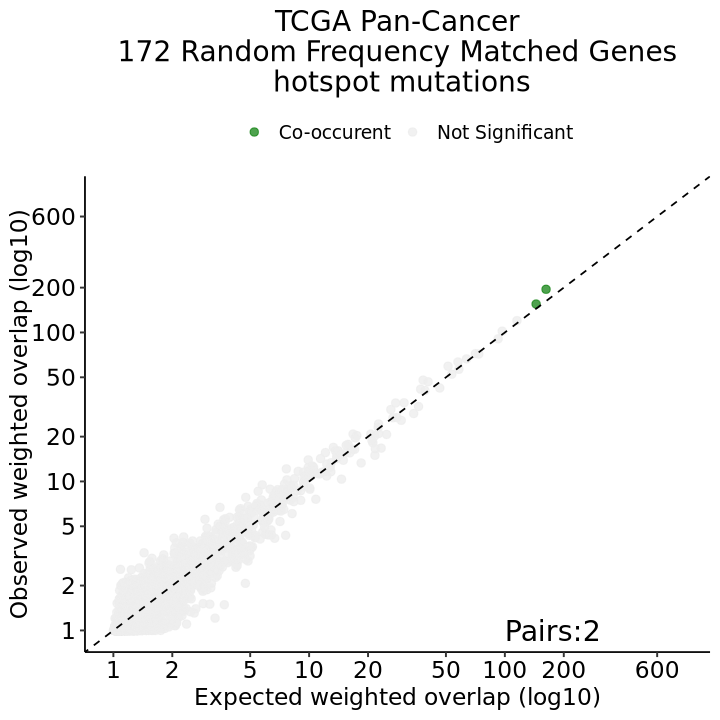

In [303]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot_random

In [304]:
p_all <- ggarrange(plot_actual,plot_random,nrow=1,ncol=2)

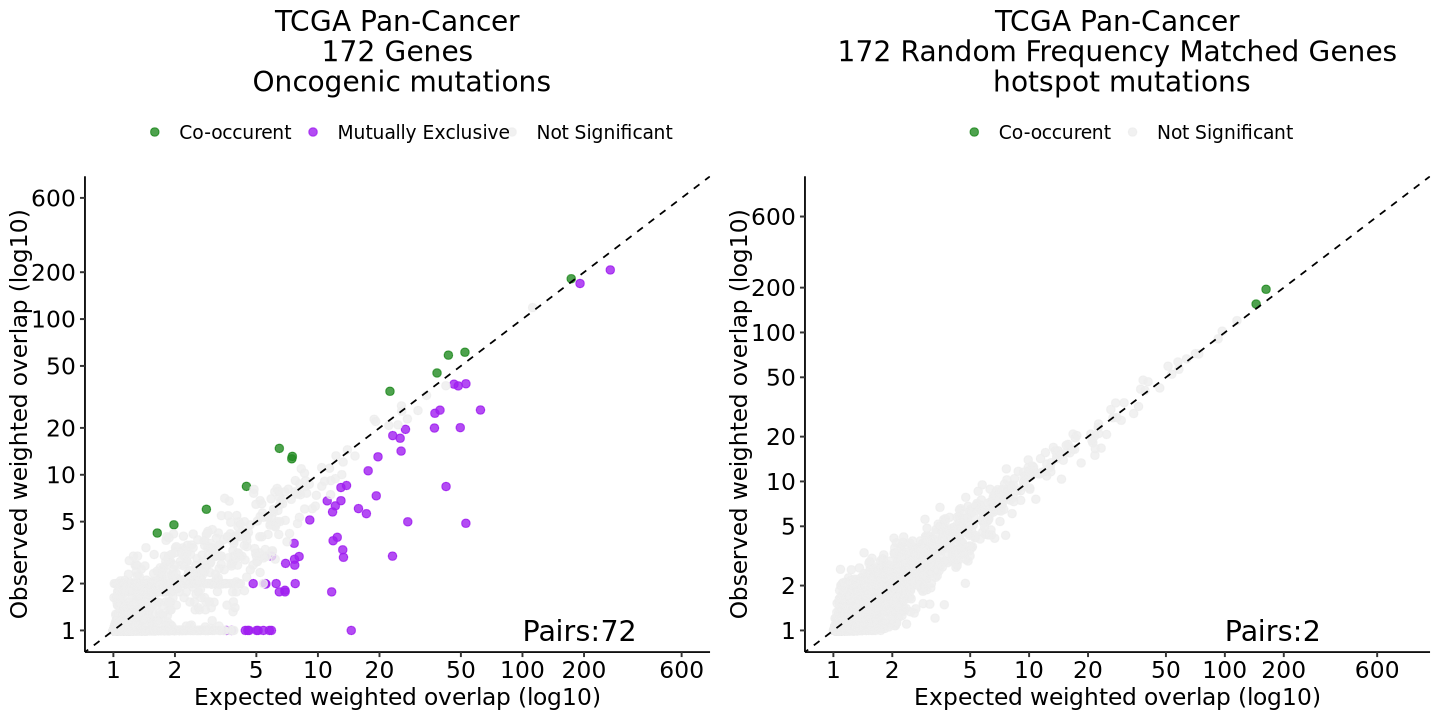

In [305]:
options(repr.plot.width=12, repr.plot.height=6)
p_all

In [306]:
df <- data.frame('Count'=significant_hit_counts,
                 'Data'=c(rep('Random',10)))

In [307]:
options(repr.plot.width=4, repr.plot.height=6)
dot_plot<-ggdotplot(df, x = "Data", y = "Count",
   add = "mean_sd",fill = "steelblue",binwidth=0.2)+
 xlab("") + 
        ylab("Count of Significant Hits")+
        ggtitle('TCGA Pan-Cancer\n Random Runs(n=10) \n Hotspot mutations') + theme_pubr() +
        theme(legend.position = "top", 
             legend.title = element_blank(),
             axis.text.x=element_blank(),
             plot.title = element_text(hjust = 0.5), 
             text = element_text(size = 16))

In [308]:
str(oncokb_run_data_missense)

List of 3
 $ M               :List of 2
  ..$ M  :List of 1
  .. ..$ missense: num [1:172, 1:9082] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:172] "AKT1" "ALK" "APC" "AR" ...
  .. .. .. ..$ : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  ..$ tmb:List of 1
  .. ..$ missense:'data.frame':	9082 obs. of  2 variables:
  .. .. ..$ sample  : chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...
  .. .. ..$ mutation: num [1:9082] 56 47 40 422 214 588 14 8 19 8 ...
 $ alteration.class: Named chr [1:172] "MUT" "MUT" "MUT" "MUT" ...
  ..- attr(*, "names")= chr [1:172] "AKT1" "ALK" "APC" "AR" ...
 $ sample.class    : Named chr [1:9082] "GBM" "GBM" "LAML" "LAML" ...
  ..- attr(*, "names")= chr [1:9082] "TCGA-02-0047-01" "TCGA-02-0055-01" "TCGA-AB-2805-03" "TCGA-AB-2806-03" ...


In [309]:
pan_can_result_df %>% filter(FDR) %>% nrow()

[1] 72

In [310]:
saveRDS(oncokb_run_data_missense,file='../results/pan_can_tcga_oncokb_frequency_matched_oncogenic_172_run_data.rds')
saveRDS(pan_can_result_df,file='../results/pan_can_tcga_oncokb_frequency_matched_oncogenic_172_result_df.rds')

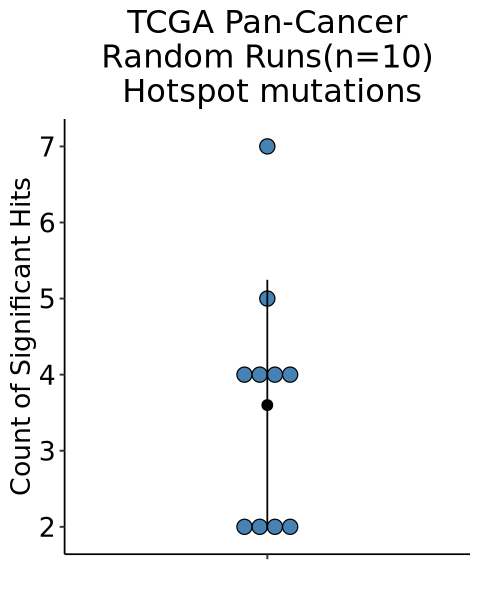

In [316]:
options(repr.plot.width=4, repr.plot.height=5)
dot_plot

In [ ]:
ggsave(p_all,filename = '../figures/pan_can_tcga_oncokb_random_frequeny_matched_scatter_plot_172.pdf',device = pdf,width = 12,height = 6)
ggsave(dot_plot,filename = '../figures/pan_can_tcga_oncokb_random_frequeny_matched_random_significant_172_dot_plot.pdf',device = pdf,width = 4,height = 6)